# Notebook 06 — Ensemble Methods and Final Evaluation

This is the final notebook in the satellite image classification pipeline. We:
1. Reload all previously trained models (custom CNN, ResNet18, EfficientNet-B0)
2. Re-train classical models (Random Forest, SVM) on full training data
3. Build and evaluate multiple ensemble strategies (soft voting, hard voting, stacking)
4. Perform comprehensive final evaluation on the held-out test set
5. Visualize GradCAM explanations for the best deep learning model
6. Conduct error analysis on misclassified samples
7. Produce a final summary of all results

## Section 1: Setup

In [1]:
import random
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tv_models
import torchvision.transforms as transforms

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, precision_recall_fscore_support
)

warnings.filterwarnings('ignore')

# --- Seeds ---
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# --- Device ---
device = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# --- Paths ---
DATA_DIR    = Path('../data_preprocessed')
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CLASSES = ['cloudy', 'desert', 'green_area', 'water']
NUM_CLASSES = len(CLASSES)
print(f"Classes: {CLASSES}")

Device: mps
Classes: ['cloudy', 'desert', 'green_area', 'water']


In [2]:
# --- Load preprocessed data ---
X_train = np.load(DATA_DIR / 'X_train.npy')
X_test  = np.load(DATA_DIR / 'X_test.npy')
y_train = np.load(DATA_DIR / 'y_train.npy')
y_test  = np.load(DATA_DIR / 'y_test.npy')

with open(DATA_DIR / 'class_mapping.json') as f:
    class_mapping = json.load(f)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")
print(f"Class mapping: {class_mapping}")

X_train: (4800, 64, 64, 3), y_train: (4800,)
X_test:  (1200, 64, 64, 3),  y_test:  (1200,)
Class mapping: {'class_to_idx': {'cloudy': 0, 'desert': 1, 'green_area': 2, 'water': 3}, 'idx_to_class': {'0': 'cloudy', '1': 'desert', '2': 'green_area', '3': 'water'}}


In [3]:
# --- Train / Validation split (same as previous notebooks) ---
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42
)
print(f"Train subset: {X_tr.shape}, Val subset: {X_val.shape}")

Train subset: (3840, 64, 64, 3), Val subset: (960, 64, 64, 3)


## Section 2: Reload All Models

In [4]:
# ── SimpleCNN definition (same as notebook 04) ────────────────────────────────
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=4, dropout_rate=0.2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        if x.shape[-1] == 3:          # HWC → CHW
            x = x.permute(0, 3, 1, 2).contiguous()
        return self.classifier(self.features(x))

print("SimpleCNN class defined.")

SimpleCNN class defined.


In [5]:
# ── SatelliteDataset (no augmentation — inference mode) ───────────────────────
class SatelliteDataset(Dataset):
    """Dataset that converts HWC numpy images to CHW float tensors."""
    def __init__(self, images, labels):
        # images: (N, H, W, C) float32 in [0,1]
        self.images = torch.tensor(images, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]          # (H, W, C)
        img = img.permute(2, 0, 1)      # → (C, H, W)
        return img, self.labels[idx]

# ── DataLoaders ───────────────────────────────────────────────────────────────
test_ds  = SatelliteDataset(X_test,  y_test)
train_ds = SatelliteDataset(X_train, y_train)
val_ds   = SatelliteDataset(X_val,   y_val)

test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=0)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=False, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=0)

print(f"Test  loader: {len(test_loader)} batches")
print(f"Train loader: {len(train_loader)} batches")

Test  loader: 19 batches
Train loader: 75 batches


In [6]:
loaded_models = {}

# ── 1. Custom CNN ─────────────────────────────────────────────────────────────
cnn_path = RESULTS_DIR / 'best_cnn_model.pth'
model_cnn = None
if cnn_path.exists():
    try:
        model_cnn = SimpleCNN(num_classes=4, dropout_rate=0.2)
        state = torch.load(cnn_path, map_location=device)
        # Support both raw state_dict or wrapped dict
        if isinstance(state, dict) and 'model_state_dict' in state:
            state = state['model_state_dict']
        model_cnn.load_state_dict(state)
        model_cnn.to(device).eval()
        loaded_models['CNN'] = model_cnn
        print("[OK] CNN loaded successfully.")
    except Exception as e:
        print(f"[SKIP] CNN loading failed: {e}")
        model_cnn = None
else:
    print(f"[SKIP] CNN weights not found at {cnn_path}")

# ── 2. ResNet18 ───────────────────────────────────────────────────────────────
r18_path = RESULTS_DIR / 'best_resnet18_model.pth'
model_r18 = None
if r18_path.exists():
    try:
        model_r18 = tv_models.resnet18(weights=None)
        model_r18.fc = nn.Linear(512, 4)
        state = torch.load(r18_path, map_location=device)
        if isinstance(state, dict) and 'model_state_dict' in state:
            state = state['model_state_dict']
        model_r18.load_state_dict(state)
        model_r18.to(device).eval()
        loaded_models['ResNet18'] = model_r18
        print("[OK] ResNet18 loaded successfully.")
    except Exception as e:
        print(f"[SKIP] ResNet18 loading failed: {e}")
        model_r18 = None
else:
    print(f"[SKIP] ResNet18 weights not found at {r18_path}")

# ── 3. EfficientNet-B0 ────────────────────────────────────────────────────────
eff_path = RESULTS_DIR / 'best_efficientnet_model.pth'
model_eff = None
if eff_path.exists():
    try:
        model_eff = tv_models.efficientnet_b0(weights=None)
        model_eff.classifier[1] = nn.Linear(1280, 4)
        state = torch.load(eff_path, map_location=device)
        if isinstance(state, dict) and 'model_state_dict' in state:
            state = state['model_state_dict']
        model_eff.load_state_dict(state)
        model_eff.to(device).eval()
        loaded_models['EfficientNet'] = model_eff
        print("[OK] EfficientNet loaded successfully.")
    except Exception as e:
        print(f"[SKIP] EfficientNet loading failed: {e}")
        model_eff = None
else:
    print(f"[SKIP] EfficientNet weights not found at {eff_path}")

print(f"\nSuccessfully loaded DL models: {list(loaded_models.keys())}")

[SKIP] CNN weights not found at ../results/best_cnn_model.pth
[OK] ResNet18 loaded successfully.
[OK] EfficientNet loaded successfully.

Successfully loaded DL models: ['ResNet18', 'EfficientNet']


## Section 3: Get Predictions from All Individual Models

In [7]:
def get_probabilities(model, loader, device):
    """Return softmax probabilities as numpy array (N, num_classes)."""
    model.eval()
    all_probs = []
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            logits = model(images)
            probs  = F.softmax(logits, dim=1)
            all_probs.append(probs.cpu().numpy())
    return np.concatenate(all_probs, axis=0)


def get_predictions(model, loader, device):
    """Return hard class predictions as numpy array (N,)."""
    probs = get_probabilities(model, loader, device)
    return np.argmax(probs, axis=1)


print("Inference helper functions defined.")

Inference helper functions defined.


In [8]:
# ── Deep Learning probabilities on TEST set ───────────────────────────────────
dl_test_probs  = {}
dl_test_preds  = {}
dl_train_probs = {}   # needed later for stacking meta-features

for name, model in loaded_models.items():
    print(f"Getting probabilities for {name} ...", end=' ')
    t0 = time.time()
    dl_test_probs[name]  = get_probabilities(model, test_loader,  device)
    dl_test_preds[name]  = np.argmax(dl_test_probs[name], axis=1)
    dl_train_probs[name] = get_probabilities(model, train_loader, device)
    acc = accuracy_score(y_test, dl_test_preds[name])
    print(f"acc={acc:.4f}  ({time.time()-t0:.1f}s)")

Getting probabilities for ResNet18 ... acc=0.9975  (2.4s)
Getting probabilities for EfficientNet ... acc=0.9967  (3.1s)


In [9]:
# ── Classical models: re-train on full X_train ────────────────────────────────
print("Preparing flat features for classical models...")
X_train_flat = X_train.reshape(len(X_train), -1).astype(np.float32)
X_test_flat  = X_test.reshape(len(X_test),  -1).astype(np.float32)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled  = scaler.transform(X_test_flat)
print(f"Feature dims — train: {X_train_scaled.shape}, test: {X_test_scaled.shape}")

# Random Forest
print("\nTraining Random Forest...", end=' ')
t0 = time.time()
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
proba_rf_test  = rf.predict_proba(X_test_scaled)
proba_rf_train = rf.predict_proba(X_train_scaled)
preds_rf = np.argmax(proba_rf_test, axis=1)
acc_rf   = accuracy_score(y_test, preds_rf)
print(f"done. acc={acc_rf:.4f}  ({time.time()-t0:.1f}s)")

# SVM
print("Training SVM...", end=' ')
t0 = time.time()
svm = SVC(C=10, kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
proba_svm_test  = svm.predict_proba(X_test_scaled)
proba_svm_train = svm.predict_proba(X_train_scaled)
preds_svm = np.argmax(proba_svm_test, axis=1)
acc_svm   = accuracy_score(y_test, preds_svm)
print(f"done. acc={acc_svm:.4f}  ({time.time()-t0:.1f}s)")

Preparing flat features for classical models...
Feature dims — train: (4800, 12288), test: (1200, 12288)

Training Random Forest... done. acc=0.9358  (2.4s)
Training SVM... done. acc=0.9217  (154.9s)


In [10]:
# ── Collect all test probabilities / predictions ──────────────────────────────
all_test_probs = {}
all_test_preds = {}
all_train_probs = {}

# DL models
for name in loaded_models.keys():
    all_test_probs[name]  = dl_test_probs[name]
    all_test_preds[name]  = dl_test_preds[name]
    all_train_probs[name] = dl_train_probs[name]

# Classical models
all_test_probs['RandomForest']  = proba_rf_test
all_test_preds['RandomForest']  = preds_rf
all_train_probs['RandomForest'] = proba_rf_train

all_test_probs['SVM']  = proba_svm_test
all_test_preds['SVM']  = preds_svm
all_train_probs['SVM'] = proba_svm_train

print("All individual model predictions collected:")
for name, preds in all_test_preds.items():
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='macro')
    print(f"  {name:15s}  acc={acc:.4f}  macro-F1={f1:.4f}")

All individual model predictions collected:
  ResNet18         acc=0.9975  macro-F1=0.9975
  EfficientNet     acc=0.9967  macro-F1=0.9967
  RandomForest     acc=0.9358  macro-F1=0.9359
  SVM              acc=0.9217  macro-F1=0.9216


## Section 4: Ensemble Strategies

### 4a: Soft Voting Ensembles

In [15]:
def soft_vote(proba_list):
    """Average probabilities from a list of (N,C) arrays and return argmax."""
    avg = np.mean(np.stack(proba_list, axis=0), axis=0)   # (N, C)
    return avg, np.argmax(avg, axis=1)


ensemble_results = []

# --- DL Ensemble (CNN + ResNet18 + EfficientNet) ---
dl_names = [n for n in ['CNN', 'ResNet18', 'EfficientNet'] if n in all_test_probs]
if len(dl_names) >= 2:
    avg_dl, preds_dl_ens = soft_vote([all_test_probs[n] for n in dl_names])
    all_test_probs['DL_Ensemble'] = avg_dl
    all_test_preds['DL_Ensemble'] = preds_dl_ens
    acc = accuracy_score(y_test, preds_dl_ens)
    f1  = f1_score(y_test, preds_dl_ens, average='macro')
    ensemble_results.append({'Ensemble': 'DL Soft Vote', 'Accuracy': acc, 'Macro F1': f1})
    print(f"DL Ensemble        acc={acc:.4f}  macro-F1={f1:.4f}  (models: {dl_names})")
else:
    print("[SKIP] DL Ensemble: fewer than 2 DL models loaded.")

# --- Classical Ensemble (RF + SVM) ---
avg_cl, preds_cl_ens = soft_vote([all_test_probs['RandomForest'], all_test_probs['SVM']])
all_test_probs['Classical_Ensemble'] = avg_cl
all_test_preds['Classical_Ensemble'] = preds_cl_ens
acc = accuracy_score(y_test, preds_cl_ens)
f1  = f1_score(y_test, preds_cl_ens, average='macro')
ensemble_results.append({'Ensemble': 'Classical Soft Vote', 'Accuracy': acc, 'Macro F1': f1})
print(f"Classical Ensemble acc={acc:.4f}  macro-F1={f1:.4f}")

# --- Full Ensemble (all 5 models) ---
full_names = [n for n in ['CNN', 'ResNet18', 'EfficientNet', 'RandomForest', 'SVM']
              if n in all_test_probs]
avg_full, preds_full_ens = soft_vote([all_test_probs[n] for n in full_names])
all_test_probs['Full_Ensemble'] = avg_full
all_test_preds['Full_Ensemble'] = preds_full_ens
acc = accuracy_score(y_test, preds_full_ens)
f1  = f1_score(y_test, preds_full_ens, average='macro')
ensemble_results.append({'Ensemble': 'Full Soft Vote (5 models)', 'Accuracy': acc, 'Macro F1': f1})
print(f"Full Ensemble      acc={acc:.4f}  macro-F1={f1:.4f}  (models: {full_names})")

# --- Best-DL + RF ---
if dl_names:
    # Pick the DL model with highest individual test accuracy
    best_dl_name = max(dl_names, key=lambda n: accuracy_score(y_test, all_test_preds[n]))
    avg_best_rf, preds_best_rf = soft_vote([all_test_probs[best_dl_name], all_test_probs['RandomForest']])
    all_test_probs['BestDL_RF_Ensemble'] = avg_best_rf
    all_test_preds['BestDL_RF_Ensemble'] = preds_best_rf
    acc = accuracy_score(y_test, preds_best_rf)
    f1  = f1_score(y_test, preds_best_rf, average='macro')
    ensemble_results.append({'Ensemble': f'Best DL ({best_dl_name}) + RF', 'Accuracy': acc, 'Macro F1': f1})
    print(f"Best DL+RF         acc={acc:.4f}  macro-F1={f1:.4f}  (DL={best_dl_name})")

DL Ensemble        acc=0.9983  macro-F1=0.9983  (models: ['ResNet18', 'EfficientNet'])
Classical Ensemble acc=0.9325  macro-F1=0.9325
Full Ensemble      acc=0.9983  macro-F1=0.9983  (models: ['ResNet18', 'EfficientNet', 'RandomForest', 'SVM'])
Best DL+RF         acc=0.9983  macro-F1=0.9983  (DL=ResNet18)


### 4b: Hard Voting Ensemble

In [16]:
from scipy import stats as scipy_stats

# Hard voting across all available individual models
hard_vote_names = [n for n in ['CNN', 'ResNet18', 'EfficientNet', 'RandomForest', 'SVM']
                   if n in all_test_preds]

# Stack predictions: (num_models, N) → majority vote per sample
stacked_preds = np.stack([all_test_preds[n] for n in hard_vote_names], axis=0)  # (M, N)
# mode along axis 0
preds_hard, _ = scipy_stats.mode(stacked_preds, axis=0, keepdims=False)
preds_hard = preds_hard.astype(int)

all_test_preds['Hard_Vote_Ensemble'] = preds_hard
acc_hv = accuracy_score(y_test, preds_hard)
f1_hv  = f1_score(y_test, preds_hard, average='macro')
ensemble_results.append({'Ensemble': 'Hard Vote (all models)', 'Accuracy': acc_hv, 'Macro F1': f1_hv})
print(f"Hard Vote Ensemble  acc={acc_hv:.4f}  macro-F1={f1_hv:.4f}  (models: {hard_vote_names})")

Hard Vote Ensemble  acc=0.9717  macro-F1=0.9716  (models: ['ResNet18', 'EfficientNet', 'RandomForest', 'SVM'])


### 4c: Stacking Ensemble

In [13]:
# ── Build meta-features (probabilities from all models on train/test) ─────────
stack_names = [n for n in ['CNN', 'ResNet18', 'EfficientNet', 'RandomForest', 'SVM']
               if n in all_train_probs]

# Train meta-features: concatenate (N_train, 4) arrays for each model → (N_train, 4*M)
meta_train = np.concatenate([all_train_probs[n] for n in stack_names], axis=1)
# Test meta-features
meta_test  = np.concatenate([all_test_probs[n]  for n in stack_names], axis=1)

print(f"Meta-feature shapes — train: {meta_train.shape}, test: {meta_test.shape}")

# ── Train LogisticRegression meta-learner ─────────────────────────────────────
meta_lr = LogisticRegression(max_iter=1000, random_state=42)
meta_lr.fit(meta_train, y_train)

preds_stack = meta_lr.predict(meta_test)
proba_stack  = meta_lr.predict_proba(meta_test)

all_test_probs['Stacking_Ensemble'] = proba_stack
all_test_preds['Stacking_Ensemble'] = preds_stack

acc_st = accuracy_score(y_test, preds_stack)
f1_st  = f1_score(y_test, preds_stack, average='macro')
ensemble_results.append({'Ensemble': 'Stacking (LR meta-learner)', 'Accuracy': acc_st, 'Macro F1': f1_st})
print(f"Stacking Ensemble   acc={acc_st:.4f}  macro-F1={f1_st:.4f}  (base models: {stack_names})")

Meta-feature shapes — train: (4800, 16), test: (1200, 16)
Stacking Ensemble   acc=0.9992  macro-F1=0.9992  (base models: ['ResNet18', 'EfficientNet', 'RandomForest', 'SVM'])


In [14]:
# ── Summary table of all ensemble results ─────────────────────────────────────
ens_df = pd.DataFrame(ensemble_results).sort_values('Accuracy', ascending=False)
ens_df = ens_df.reset_index(drop=True)
ens_df['Accuracy'] = ens_df['Accuracy'].map('{:.4f}'.format)
ens_df['Macro F1'] = ens_df['Macro F1'].map('{:.4f}'.format)
print("\n=== Ensemble Results ===")
print(ens_df.to_string(index=False))


=== Ensemble Results ===
                  Ensemble Accuracy Macro F1
Stacking (LR meta-learner)   0.9992   0.9992
              DL Soft Vote   0.9983   0.9983
 Full Soft Vote (5 models)   0.9983   0.9983
   Best DL (ResNet18) + RF   0.9983   0.9983
    Hard Vote (all models)   0.9717   0.9716
       Classical Soft Vote   0.9325   0.9325


## Section 5: Final Test-Set Evaluation (Locked)

In [17]:
# ── Identify best overall model ───────────────────────────────────────────────
eval_names = [n for n in all_test_preds.keys()]

best_model_name = max(
    eval_names,
    key=lambda n: accuracy_score(y_test, np.array(all_test_preds[n]).ravel())
)
best_acc = accuracy_score(y_test, np.array(all_test_preds[best_model_name]).ravel())
print(f"Best overall model: {best_model_name}  (test acc = {best_acc:.4f})")

Best overall model: Stacking_Ensemble  (test acc = 0.9992)


In [18]:
# ── Per-model metrics (all individual + best ensemble) ────────────────────────
individual_names = ['CNN', 'ResNet18', 'EfficientNet', 'RandomForest', 'SVM']
individual_names = [n for n in individual_names if n in all_test_preds]

# Include best ensemble
eval_set = individual_names.copy()
if best_model_name not in eval_set:
    eval_set.append(best_model_name)

final_metrics = []
for name in eval_set:
    preds = np.array(all_test_preds[name]).ravel()
    acc   = accuracy_score(y_test, preds)
    f1    = f1_score(y_test, preds, average='macro')
    prec, rec, f1_per, _ = precision_recall_fscore_support(y_test, preds, average=None, labels=list(range(NUM_CLASSES)))
    row = {'Model': name, 'Accuracy': acc, 'Macro F1': f1}
    for i, cls in enumerate(CLASSES):
        row[f'Prec_{cls}']  = prec[i]
        row[f'Rec_{cls}']   = rec[i]
        row[f'F1_{cls}']    = f1_per[i]
    final_metrics.append(row)

final_df = pd.DataFrame(final_metrics)
print("\n=== Final Test-Set Metrics ===")
print(final_df[['Model', 'Accuracy', 'Macro F1']].to_string(index=False))


=== Final Test-Set Metrics ===
            Model  Accuracy  Macro F1
         ResNet18  0.997500  0.997500
     EfficientNet  0.996667  0.996667
     RandomForest  0.935833  0.935895
              SVM  0.921667  0.921578
Stacking_Ensemble  0.999167  0.999167


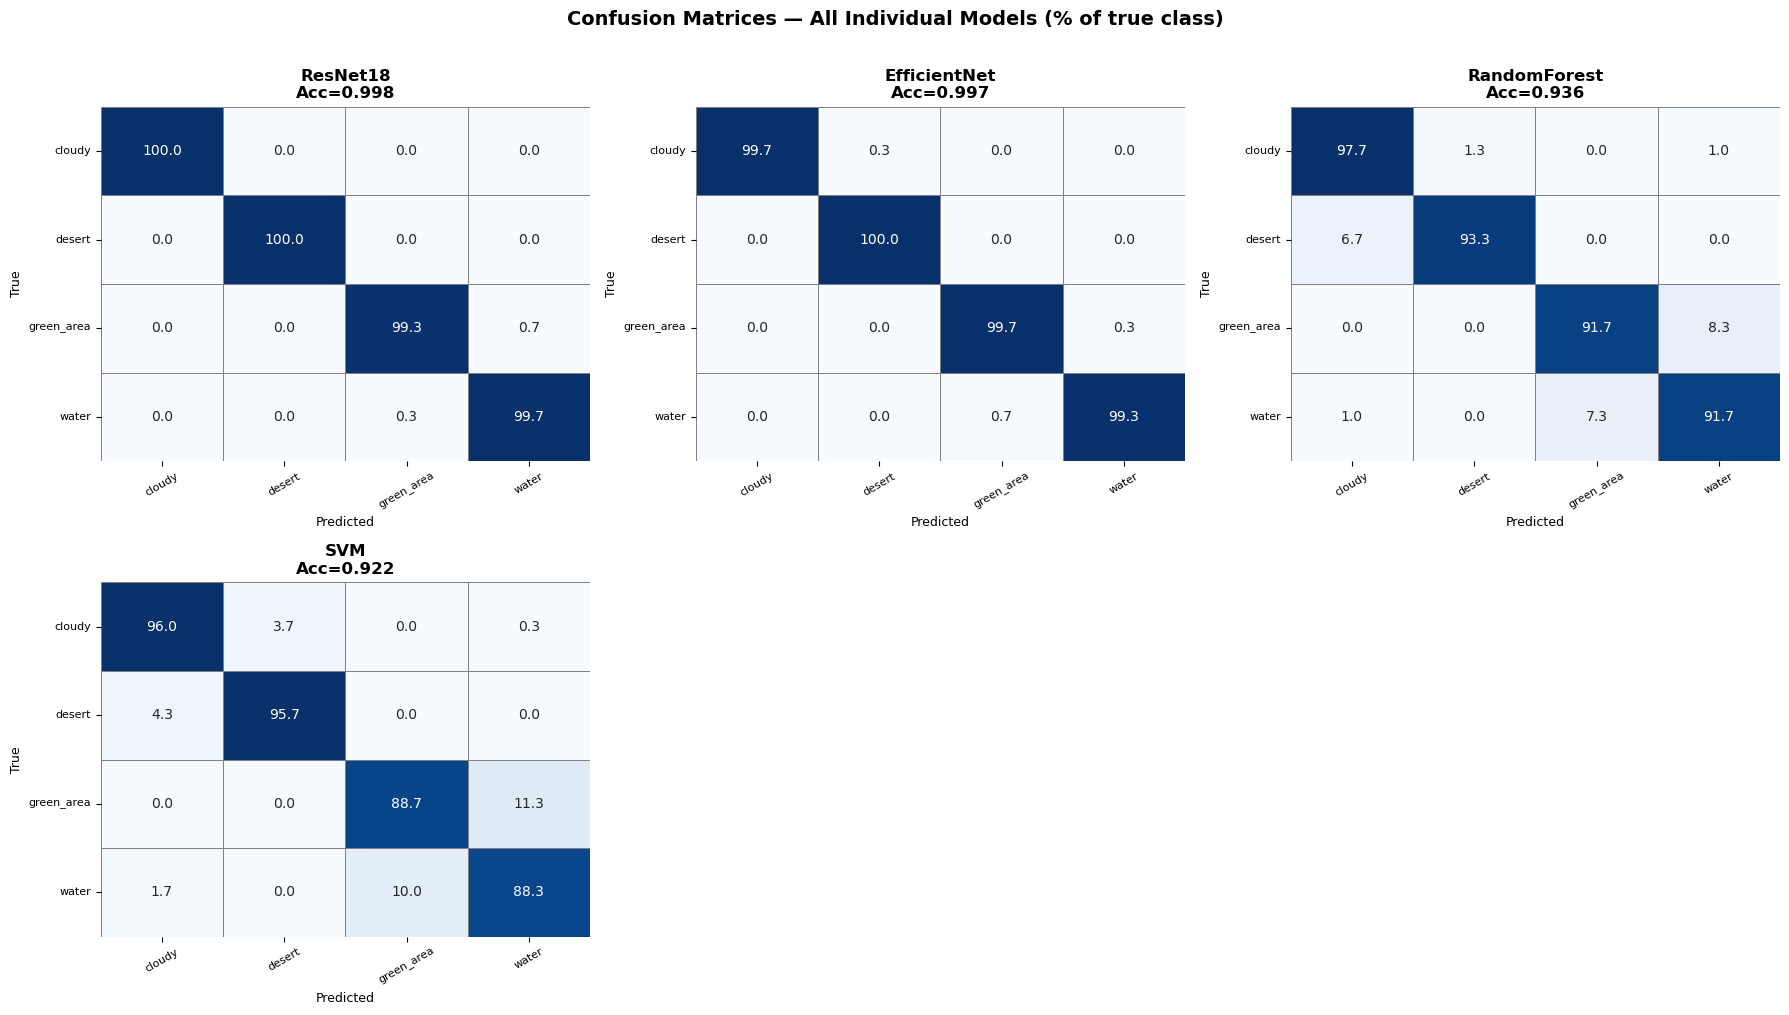

Saved: final_all_confusion_matrices.png


In [19]:
# ── Figure 1: Confusion matrices for all individual models ────────────────────
n_models  = len(individual_names)
n_cols    = 3
n_rows    = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = np.array(axes).ravel()

for idx, name in enumerate(individual_names):
    ax   = axes[idx]
    preds = np.array(all_test_preds[name]).ravel()
    cm    = confusion_matrix(y_test, preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.5, linecolor='gray', cbar=False)
    acc = accuracy_score(y_test, preds)
    ax.set_title(f'{name}\nAcc={acc:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

# Hide any unused axes
for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Confusion Matrices — All Individual Models (% of true class)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'final_all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: final_all_confusion_matrices.png")

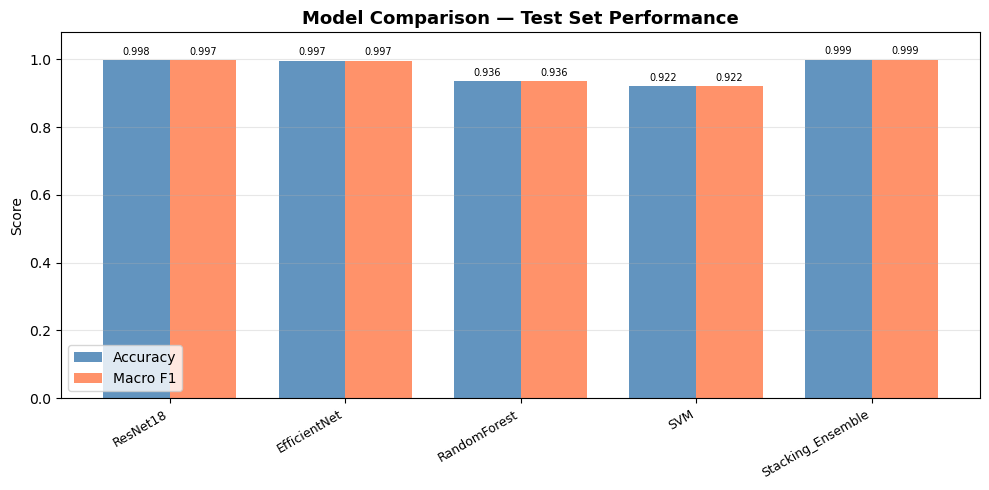

Saved: final_model_comparison.png


In [20]:
# ── Figure 2: Accuracy and Macro-F1 bar chart (all models + best ensemble) ────
plot_names = eval_set
accs = [accuracy_score(y_test, np.array(all_test_preds[n]).ravel()) for n in plot_names]
f1s  = [f1_score(y_test, np.array(all_test_preds[n]).ravel(), average='macro') for n in plot_names]

x     = np.arange(len(plot_names))
width = 0.38

fig, ax = plt.subplots(figsize=(max(10, len(plot_names) * 1.5), 5))
bars1 = ax.bar(x - width / 2, accs, width, label='Accuracy',  color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width / 2, f1s,  width, label='Macro F1',  color='coral',     alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(plot_names, rotation=30, ha='right', fontsize=9)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Test Set Performance', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: final_model_comparison.png")

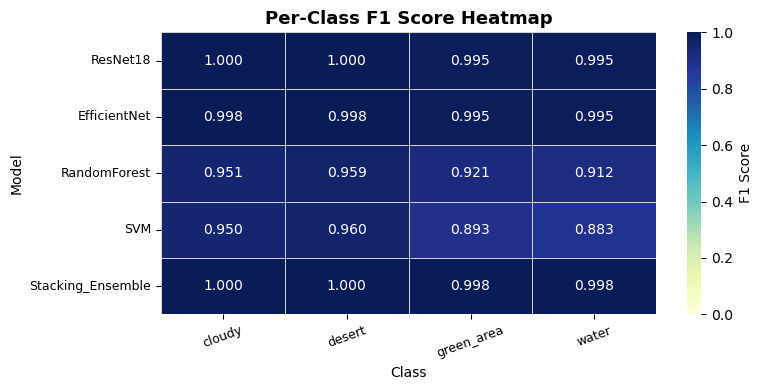

Saved: final_perclass_f1_heatmap.png


In [21]:
# ── Figure 3: Per-class F1 heatmap ────────────────────────────────────────────
f1_matrix = []
for name in eval_set:
    preds = np.array(all_test_preds[name]).ravel()
    _, _, f1_per, _ = precision_recall_fscore_support(
        y_test, preds, average=None, labels=list(range(NUM_CLASSES))
    )
    f1_matrix.append(f1_per)

f1_heatmap_df = pd.DataFrame(f1_matrix, index=eval_set, columns=CLASSES)

fig, ax = plt.subplots(figsize=(8, max(4, len(eval_set) * 0.7)))
sns.heatmap(f1_heatmap_df, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax,
            vmin=0, vmax=1, linewidths=0.5, linecolor='lightgray', cbar_kws={'label': 'F1 Score'})
ax.set_title('Per-Class F1 Score Heatmap', fontsize=13, fontweight='bold')
ax.set_xlabel('Class', fontsize=10)
ax.set_ylabel('Model', fontsize=10)
ax.tick_params(axis='x', rotation=20, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'final_perclass_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: final_perclass_f1_heatmap.png")

## Section 6: GradCAM Visualization

We implement GradCAM manually using PyTorch hooks. The target is the last convolutional layer of the best DL model.

In [22]:
# ── Choose best DL model for GradCAM ─────────────────────────────────────────
dl_candidate_names = [n for n in ['ResNet18', 'EfficientNet', 'CNN'] if n in loaded_models]
if dl_candidate_names:
    best_dl_for_cam = max(
        dl_candidate_names,
        key=lambda n: accuracy_score(y_test, all_test_preds[n])
    )
    cam_model = loaded_models[best_dl_for_cam]
    print(f"GradCAM target model: {best_dl_for_cam}")
else:
    cam_model = None
    best_dl_for_cam = None
    print("No DL model available for GradCAM.")

GradCAM target model: ResNet18


In [23]:
class GradCAM:
    """Manual GradCAM implementation using forward/backward hooks."""

    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        self._register_hooks(target_layer)

    def _register_hooks(self, layer):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        layer.register_forward_hook(forward_hook)
        layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        """
        input_tensor: (1, C, H, W) — already on device
        Returns: cam (H, W) numpy array in [0, 1]
        """
        self.model.eval()
        input_tensor = input_tensor.requires_grad_(True)

        logits = self.model(input_tensor)                      # (1, num_classes)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()

        self.model.zero_grad()
        score = logits[0, class_idx]
        score.backward()

        # Global average pool of gradients: (C,)
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # (1, C, 1, 1)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # (1, 1, h, w)
        cam = F.relu(cam)
        cam = cam.squeeze().cpu().numpy()                        # (h, w)

        # Normalize to [0, 1]
        cam_min, cam_max = cam.min(), cam.max()
        if cam_max - cam_min > 1e-8:
            cam = (cam - cam_min) / (cam_max - cam_min)
        return cam, class_idx


def get_target_layer(model, model_name):
    """Return the last convolutional layer for GradCAM."""
    if model_name == 'ResNet18':
        return model.layer4[-1].conv2
    elif model_name == 'EfficientNet':
        # Last conv block in EfficientNet-B0
        return model.features[-1][0]
    elif model_name == 'CNN':
        # Third conv block
        return model.features[8]   # nn.Conv2d(64,128,...)
    else:
        raise ValueError(f"Unknown model: {model_name}")


print("GradCAM class defined.")

GradCAM class defined.


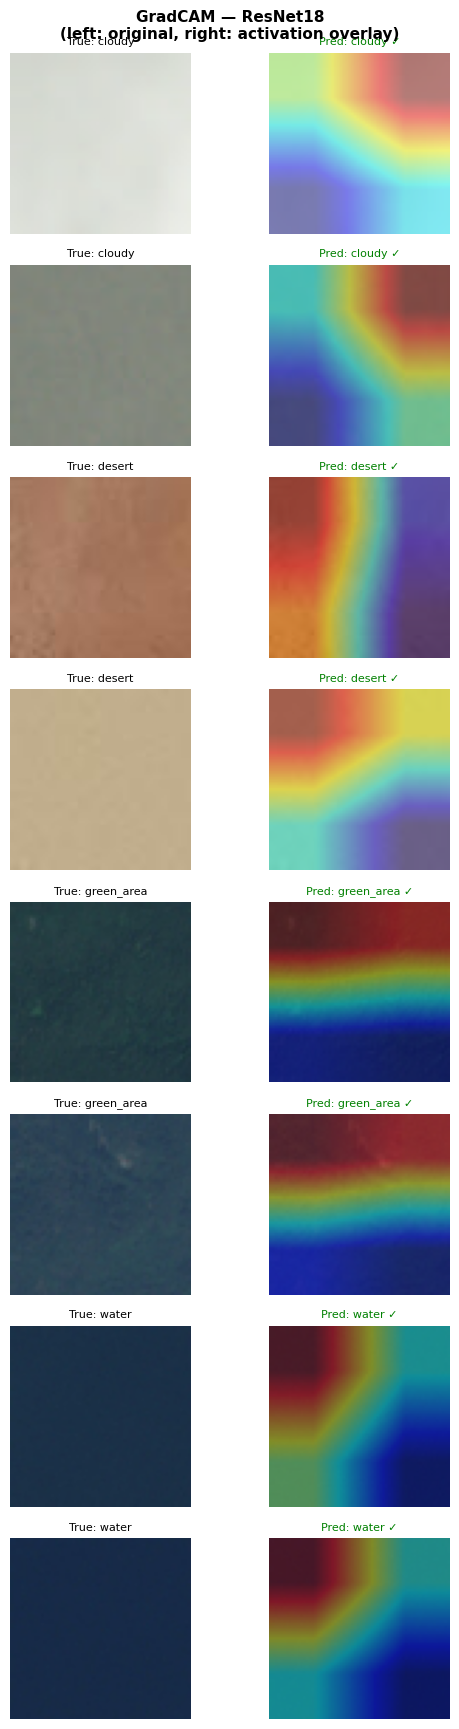

Saved: gradcam_visualization.png


In [24]:
import cv2
from matplotlib.colors import LinearSegmentedColormap


def overlay_cam_on_image(img_hwc, cam_hw, alpha=0.45):
    """
    img_hwc : (H, W, 3) float32 in [0,1]
    cam_hw  : (h, w) float32 in [0,1]  (may be smaller than img)
    Returns  : (H, W, 3) float32 in [0,1]
    """
    H, W = img_hwc.shape[:2]
    cam_resized = cv2.resize(cam_hw, (W, H), interpolation=cv2.INTER_LINEAR)

    # Apply jet colormap
    cam_uint8  = (cam_resized * 255).astype(np.uint8)
    heatmap    = cv2.applyColorMap(cam_uint8, cv2.COLORMAP_JET)    # (H, W, 3) BGR
    heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0  # (H, W, 3) [0,1]

    overlay = alpha * heatmap_rgb + (1 - alpha) * img_hwc
    return np.clip(overlay, 0, 1)


if cam_model is not None:
    try:
        target_layer = get_target_layer(cam_model, best_dl_for_cam)
        grad_cam     = GradCAM(cam_model, target_layer)

        # Sample 2 test images per class
        sample_indices = []
        for cls_idx in range(NUM_CLASSES):
            idxs = np.where(y_test == cls_idx)[0]
            chosen = np.random.choice(idxs, size=min(2, len(idxs)), replace=False)
            sample_indices.extend(chosen.tolist())

        n_samples = len(sample_indices)
        fig, axes = plt.subplots(n_samples, 2, figsize=(6, n_samples * 2.2))
        if n_samples == 1:
            axes = axes[np.newaxis, :]

        for row, idx in enumerate(sample_indices):
            img_hwc = X_test[idx]                               # (H, W, 3) [0,1]
            tensor  = torch.tensor(img_hwc, dtype=torch.float32)\
                           .permute(2, 0, 1).unsqueeze(0).to(device)  # (1,3,H,W)

            cam_map, pred_cls = grad_cam.generate(tensor)
            overlay = overlay_cam_on_image(img_hwc, cam_map)

            true_label = CLASSES[y_test[idx]]
            pred_label = CLASSES[pred_cls]
            match_sym  = '✓' if pred_cls == y_test[idx] else '✗'

            axes[row, 0].imshow(img_hwc)
            axes[row, 0].set_title(f'True: {true_label}', fontsize=8)
            axes[row, 0].axis('off')

            axes[row, 1].imshow(overlay)
            axes[row, 1].set_title(f'Pred: {pred_label} {match_sym}', fontsize=8,
                                   color='green' if pred_cls == y_test[idx] else 'red')
            axes[row, 1].axis('off')

        plt.suptitle(f'GradCAM — {best_dl_for_cam}\n(left: original, right: activation overlay)',
                     fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / 'gradcam_visualization.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved: gradcam_visualization.png")

    except Exception as e:
        print(f"[GradCAM] Failed: {e}")
        import traceback; traceback.print_exc()
else:
    print("No DL model loaded — GradCAM skipped.")

## Section 7: Error Analysis

In [25]:
# ── Use best individual DL model for error analysis ───────────────────────────
# Fall back to best available model if no DL model loaded
error_model_name = best_dl_for_cam if best_dl_for_cam else best_model_name
error_preds = np.array(all_test_preds[error_model_name]).ravel()

misclassified_mask = error_preds != y_test
mis_indices = np.where(misclassified_mask)[0]
print(f"Model: {error_model_name}")
print(f"Misclassified: {len(mis_indices)} / {len(y_test)}  "
      f"({100 * len(mis_indices) / len(y_test):.1f}%)")

Model: ResNet18
Misclassified: 3 / 1200  (0.2%)


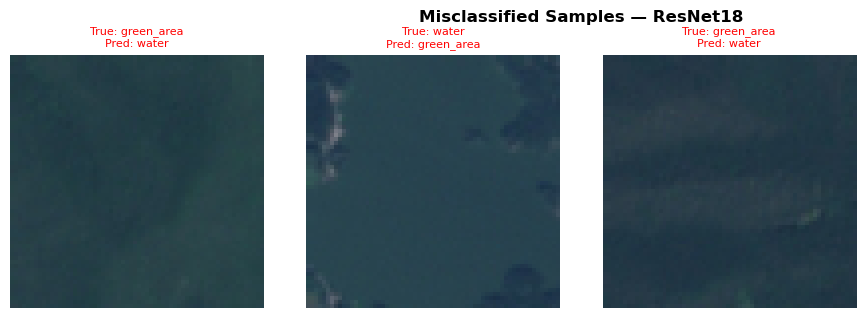

Saved: error_analysis_misclassified.png


In [26]:
# ── Show 12 misclassified images ──────────────────────────────────────────────
n_show = min(12, len(mis_indices))
show_idx = np.random.choice(mis_indices, size=n_show, replace=False)
show_idx = sorted(show_idx)

n_cols = 4
n_rows = int(np.ceil(n_show / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3.2))
axes = np.array(axes).ravel()

for i, idx in enumerate(show_idx):
    ax = axes[i]
    ax.imshow(X_test[idx])
    true_lbl = CLASSES[y_test[idx]]
    pred_lbl = CLASSES[error_preds[idx]]
    ax.set_title(f'True: {true_lbl}\nPred: {pred_lbl}',
                 fontsize=8, color='red')
    ax.axis('off')

for i in range(n_show, len(axes)):
    axes[i].set_visible(False)

plt.suptitle(f'Misclassified Samples — {error_model_name}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'error_analysis_misclassified.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: error_analysis_misclassified.png")

In [27]:
# ── Confusion analysis: which class pairs are most confused ───────────────────
cm_err = confusion_matrix(y_test, error_preds)
print(f"\nConfusion Matrix — {error_model_name}:")
cm_df = pd.DataFrame(cm_err, index=CLASSES, columns=CLASSES)
print(cm_df)

print("\nOff-diagonal confusion pairs (sorted by count):")
confusion_pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm_err[i, j] > 0:
            confusion_pairs.append({
                'True':      CLASSES[i],
                'Predicted': CLASSES[j],
                'Count':     cm_err[i, j],
                'Rate (%)':  round(100 * cm_err[i, j] / cm_err[i].sum(), 1)
            })

conf_pairs_df = pd.DataFrame(confusion_pairs).sort_values('Count', ascending=False)
print(conf_pairs_df.to_string(index=False))


Confusion Matrix — ResNet18:
            cloudy  desert  green_area  water
cloudy         300       0           0      0
desert           0     300           0      0
green_area       0       0         298      2
water            0       0           1    299

Off-diagonal confusion pairs (sorted by count):
      True  Predicted  Count  Rate (%)
green_area      water      2       0.7
     water green_area      1       0.3


## Section 8: Final Summary Table

In [28]:
# ── Build comprehensive summary DataFrame ─────────────────────────────────────
training_approach = {
    'CNN':                       'Custom CNN (notebook 04)',
    'ResNet18':                  'Transfer Learning ResNet18 (notebook 05)',
    'EfficientNet':              'Transfer Learning EfficientNet-B0 (notebook 05)',
    'RandomForest':              'Ensemble Trees — classical ML (notebook 03)',
    'SVM':                       'Kernel SVM — classical ML (notebook 03)',
    'DL_Ensemble':               'Soft Voting — DL models only',
    'Classical_Ensemble':        'Soft Voting — classical models only',
    'Full_Ensemble':             'Soft Voting — all 5 models',
    'BestDL_RF_Ensemble':        'Soft Voting — best DL + RF',
    'Hard_Vote_Ensemble':        'Hard Majority Voting — all models',
    'Stacking_Ensemble':         'Stacking — LR meta-learner on proba features',
}

summary_rows = []
all_eval_names = list(all_test_preds.keys())

for name in all_eval_names:
    preds = np.array(all_test_preds[name]).ravel()
    acc   = accuracy_score(y_test, preds)
    f1    = f1_score(y_test, preds, average='macro')
    approach = training_approach.get(name, 'Ensemble / Other')
    summary_rows.append({
        'Model':             name,
        'Accuracy':          round(acc, 4),
        'Macro F1':          round(f1, 4),
        'Training Approach': approach,
    })

summary_df = pd.DataFrame(summary_rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)
summary_df.index += 1

print("=" * 80)
print("FINAL SUMMARY — All Models")
print("=" * 80)
print(summary_df.to_string())
print("=" * 80)

FINAL SUMMARY — All Models
                 Model  Accuracy  Macro F1                                Training Approach
1    Stacking_Ensemble    0.9992    0.9992     Stacking — LR meta-learner on proba features
2          DL_Ensemble    0.9983    0.9983                     Soft Voting — DL models only
3        Full_Ensemble    0.9983    0.9983                       Soft Voting — all 5 models
4   BestDL_RF_Ensemble    0.9983    0.9983                       Soft Voting — best DL + RF
5             ResNet18    0.9975    0.9975         Transfer Learning ResNet18 (notebook 05)
6         EfficientNet    0.9967    0.9967  Transfer Learning EfficientNet-B0 (notebook 05)
7   Hard_Vote_Ensemble    0.9717    0.9716                Hard Majority Voting — all models
8         RandomForest    0.9358    0.9359      Ensemble Trees — classical ML (notebook 03)
9   Classical_Ensemble    0.9325    0.9325              Soft Voting — classical models only
10                 SVM    0.9217    0.9216          K

In [29]:
# ── Save comprehensive CSV ─────────────────────────────────────────────────────
csv_path = RESULTS_DIR / 'model_comparison.csv'
summary_df.to_csv(csv_path, index=True)
print(f"Saved: {csv_path}")

# ── Top-3 models ───────────────────────────────────────────────────────────────
print("\n=== Top-3 Models ===")
print(summary_df.head(3)[['Model', 'Accuracy', 'Macro F1', 'Training Approach']].to_string())

Saved: ../results/model_comparison.csv

=== Top-3 Models ===
               Model  Accuracy  Macro F1                             Training Approach
1  Stacking_Ensemble    0.9992    0.9992  Stacking — LR meta-learner on proba features
2        DL_Ensemble    0.9983    0.9983                  Soft Voting — DL models only
3      Full_Ensemble    0.9983    0.9983                    Soft Voting — all 5 models


In [30]:
# ── Final print-out ────────────────────────────────────────────────────────────
best_row = summary_df.iloc[0]
print("\n" + "=" * 60)
print("FINAL PROJECT RESULTS SUMMARY")
print("=" * 60)
print(f"Task          : 4-class satellite image classification")
print(f"Image size    : 64 x 64 x 3 (RGB, normalised)")
print(f"Classes       : {', '.join(CLASSES)}")
print(f"Test set size : {len(y_test)} images")
print(f"")
print(f"Best model    : {best_row['Model']}")
print(f"  Accuracy    : {best_row['Accuracy']:.4f}")
print(f"  Macro F1    : {best_row['Macro F1']:.4f}")
print(f"  Approach    : {best_row['Training Approach']}")
print("=" * 60)
print("All result files saved to:", RESULTS_DIR.resolve())


FINAL PROJECT RESULTS SUMMARY
Task          : 4-class satellite image classification
Image size    : 64 x 64 x 3 (RGB, normalised)
Classes       : cloudy, desert, green_area, water
Test set size : 1200 images

Best model    : Stacking_Ensemble
  Accuracy    : 0.9992
  Macro F1    : 0.9992
  Approach    : Stacking — LR meta-learner on proba features
All result files saved to: /Users/michelangelonardi/Desktop/Università/Master/BocconiMaster/Year2/Semester2_UW/AI_for_Agriculture/FinalProject/AI_agri_project/results
